#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Data

In [3]:
index_selection = ['Pyrimidine metabolism', 'Purine metabolism']

In [4]:
mcf7_untargeted = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/MetaboAnalyst_untargeted/MCF7_untargeted.csv', index_col = 0)
mcf7_untargeted = mcf7_untargeted.loc[index_selection]
mcf7_untargeted

,Pathway total,Hits.total,Hits.sig,Expected,P(Fisher),P(EASE),P(Gamma),Emp.Hits,Empirical,AdjP.Fisher,AdjP.EASE,AdjP.Gamma,Pathway Number,cpd.hits
Pyrimidine metabolism,70,51,37,16.235,0.007170,0.015416,0.028851,10,0.10,0.659677,1.0,1,P10,C00106;C01801;C00022;C00143;C00063;C00029;C002...
Purine metabolism,80,57,40,18.554,0.012974,0.025183,0.029502,9,0.09,1.000000,1.0,1,P14,C00025;C00027;C00362;C00020;C00360;C00361;C001...


In [5]:
mcf7_untargeted_rna = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/MetaboAnalyst_untargeted/MCF7_untargeted_RNASeq.csv', index_col = 0)
mcf7_untargeted_rna = mcf7_untargeted_rna.loc[index_selection]
mcf7_untargeted_rna

,Pathway total,Hits.total,Hits.sig,Expected,P(Fisher),P(EASE),P(Gamma),Emp.Hits,Empirical,AdjP.Fisher,AdjP.EASE,AdjP.Gamma,Pathway Number,cpd.hits
Pyrimidine metabolism,39,33,14,10.452,0.48904,0.62525,0.076271,43,0.43,1.0,1.0,1.0,P21,C00015;C01103;C00105;C00299;C00063;C00458;C008...
Purine metabolism,70,55,21,18.760,0.70590,0.79073,0.137360,22,0.22,1.0,1.0,1.0,P27,C00117;C03090;C03838;C04823;C00212;C00360;C055...


In [7]:
mcf10a_untargeted = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/MetaboAnalyst_untargeted/MCF10A_untargeted_pooled_E5&H10_vs_WT.csv', index_col = 0)
mcf10a_untargeted = mcf10a_untargeted.loc[index_selection]
mcf10a_untargeted

,Pathway total,Hits.total,Hits.sig,Expected,P(Fisher),P(EASE),P(Gamma),Emp.Hits,Empirical,AdjP.Fisher,AdjP.EASE,AdjP.Gamma,Pathway Number,cpd.hits
Pyrimidine metabolism,70,46,28,11.709,0.001937,0.004691,0.019406,6,0.06,0.187928,0.454988,1,P6,C00106;C00022;C00029;C00064;C05100;C00025;C009...
Purine metabolism,80,47,30,13.382,0.000418,0.001136,0.019237,3,0.03,0.040981,0.112454,1,P4,C00025;C00027;C00942;C04677;C00212;C00147;C005...


In [8]:
mcf10a_untargeted_rna = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/MetaboAnalyst_untargeted/MCF10A_untargeted_RNASeq_pooled_E5&H10_vs_WT.csv', index_col = 0)
mcf10a_untargeted_rna = mcf10a_untargeted_rna.loc[index_selection]
mcf10a_untargeted_rna

,Pathway total,Hits.total,Hits.sig,Expected,P(Fisher),P(EASE),P(Gamma),Emp.Hits,Empirical,AdjP.Fisher,AdjP.EASE,AdjP.Gamma,Pathway Number,cpd.hits
Pyrimidine metabolism,39,34,19,10.892,0.09400,0.16302,0.036336,12,0.12,1.0,1.0,1,P12,C00064;C00075;C00299;C00429;C02642;C00239;C008...
Purine metabolism,70,45,23,19.549,0.18017,0.26571,0.046493,19,0.19,1.0,1.0,1,P18,C00385;C00064;C00119;C03090;C04677;C04734;C001...


In [9]:
def get_pathway_score(df, data_name):
  df['Score'] = df['Pathway total'] / df['Hits.sig'].sum()
  df = df[['Score']]
  df = df.rename(columns = {'Score' : data_name})
  return df

In [10]:
mcf7_untargeted = get_pathway_score(df = mcf7_untargeted, data_name = 'MCF7_untargeted_Score')
display(mcf7_untargeted)

mcf7_untargeted_rna = get_pathway_score(df = mcf7_untargeted_rna, data_name = 'MCF7_untargeted_RNA_Score')
display(mcf7_untargeted_rna)

mcf10a_untargeted = get_pathway_score(df = mcf10a_untargeted, data_name = 'MCF10A_untargeted_Score')
display(mcf10a_untargeted)

mcf10a_untargeted_rna = get_pathway_score(df = mcf10a_untargeted_rna, data_name = 'MCF10A_untargeted_RNA_Score')
display(mcf10a_untargeted_rna)

,MCF7_untargeted_Score
Pyrimidine metabolism,0.909091
Purine metabolism,1.038961


,MCF7_untargeted_RNA_Score
Pyrimidine metabolism,1.114286
Purine metabolism,2.000000


,MCF10A_untargeted_Score
Pyrimidine metabolism,1.206897
Purine metabolism,1.379310


,MCF10A_untargeted_RNA_Score
Pyrimidine metabolism,0.928571
Purine metabolism,1.666667


In [11]:
all_data = pd.concat([mcf7_untargeted, mcf7_untargeted_rna, mcf10a_untargeted, mcf10a_untargeted_rna], axis = 'columns')
all_data

,MCF7_untargeted_Score,MCF7_untargeted_RNA_Score,MCF10A_untargeted_Score,MCF10A_untargeted_RNA_Score
Pyrimidine metabolism,0.909091,1.114286,1.206897,0.928571
Purine metabolism,1.038961,2.000000,1.379310,1.666667


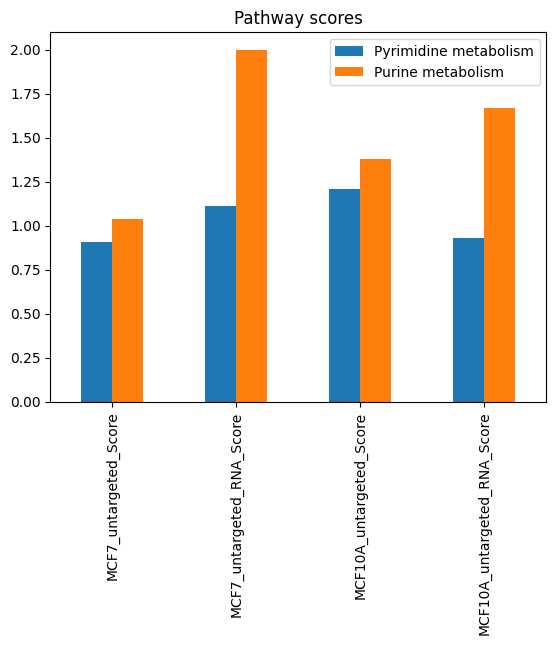

In [13]:
all_data.T.plot(kind = 'bar', title = 'Pathway scores')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/mcf7_mcf10a_metaboanalyst_pathway_scores.svg', bbox_inches = 'tight')